In [1]:
import warnings
import logging
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import albumentations as A
import matplotlib.colors as mcolors
import time


from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

import thor_terratorch_ext
from terratorch.datamodules import GenericMultiModalDataModule
from terratorch.tasks import SemanticSegmentationTask

warnings.filterwarnings("ignore", category=UserWarning, module=r"rich\.live")
warnings.filterwarnings("ignore", message=r".*does not have many workers.*")
warnings.filterwarnings("ignore", message=r".*LeafSpec.*deprecated.*")

logging.getLogger("terratorch").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

torch.set_float32_matmul_precision("medium")

/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO:thor.models.patch_timm:Patching timm Attention and Block to use Alibi...
INFO:thor.models.patch_timm:Using normal attention for timm Attention


In [ ]:
dataset_root = Path("/home/predm/venvs/thor_terratorch_ext/skimage_segmentation_sorted")

s1_images = dataset_root / "tif_images"
doppler_images = dataset_root / "tif_doppler"
masks_dir = dataset_root / "tif_mask"
splits_dir = dataset_root / "splits"

experiment = "thor_s1_doppler_notebook_run0"
log_root = Path("/home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results")
default_root_dir = log_root / experiment
default_root_dir.mkdir(parents=True, exist_ok=True)

MAX_EPOCHS = 200

S1_BANDS = ["EW_HH_80", "EW_HV_80"]
DOPPLER_BANDS = ["DOPPLER"]

S1_MEANS = [141.93311161242033, 122.23673553466797]
S1_STDS = [53.95834372765628, 47.42699242760452]

DOPPLER_MEANS = [139.4596141614412]
DOPPLER_STDS = [40.77621061122129]

NUM_CLASSES = 2

In [ ]:
datamodule = GenericMultiModalDataModule(
    task="segmentation",
    batch_size=4,
    num_workers=0,
    modalities=["S1", "DOPPLER"],
    rgb_modality="S1",
    rgb_indices=[0, 1, 1],
    train_data_root={
        "S1": str(s1_images),
        "DOPPLER": str(doppler_images),
    },
    train_label_data_root=str(masks_dir),
    val_data_root={
        "S1": str(s1_images),
        "DOPPLER": str(doppler_images),
    },
    val_label_data_root=str(masks_dir),
    test_data_root={
        "S1": str(s1_images),
        "DOPPLER": str(doppler_images),
    },
    test_label_data_root=str(masks_dir),
    train_split=str(splits_dir / "train.txt"),
    val_split=str(splits_dir / "val.txt"),
    test_split=str(splits_dir / "test.txt"),
    allow_substring_file_names=True,
    image_grep={
        "S1": "*.tif",
        "DOPPLER": "*_doppler.tif",
    },
    label_grep="*_mask.tif",
    no_label_replace=-1,
    no_data_replace=0,
    concat_bands=True,
    check_stackability=False,
    dataset_bands={
        "S1": S1_BANDS,
        "DOPPLER": DOPPLER_BANDS,
    },
    means={
        "S1": S1_MEANS,
        "DOPPLER": DOPPLER_MEANS,
    },
    stds={
        "S1": S1_STDS,
        "DOPPLER": DOPPLER_STDS,
    },
    num_classes=NUM_CLASSES,
    train_transform=[
        A.RandomCrop(height=288, width=288),
        A.D4(),
        A.pytorch.transforms.ToTensorV2(),
    ],
)

datamodule.setup("fit")
print("train size:", len(datamodule.train_dataset))
print("val size:", len(datamodule.val_dataset))

train size: 95
val size: 20


/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/terratorch/datamodules/generic_multimodal_data_module.py:482: UserWarning: rgb_modality is deprecated and will be removed in a future release. Provide the modalities for plotting as keys in `rgb_indices` with the format {'<modality>': [<band indices>]}.
  warnings.warn("rgb_modality is deprecated and will be removed in a future release. Provide the modalities "


In [ ]:
model_args = {
    "backbone": "MultiBackboneWrapper",
    "backbone_bands": [
        "EW_HH_80",
        "EW_HV_80",
        "DOPPLER",
    ],
    "backbone_merge_features": "concat",
    "backbone_rescale_features": "down",
    "backbone_encoders": [
        {
            "thor_v1_base": {
                "freeze_backbone": True,
                "backbone_merge_method": "concat",
                "backbone_pretrained": True,
                "backbone_ground_cover": 23040,
                "backbone_patch_sizes": 16,
                "backbone_out_indices": [-1],
                "backbone_model_bands": [
                    "EW_HH_80",
                    "EW_HV_80",
                ],
            }
        },
        {
            "vit_small_patch16_224.dino": {
                "out_indices": [-1],
                "in_chans": 1,
                "backbone_pretrained": True,
                "backbone_dynamic_img_size": True,
                "bands": ["DOPPLER"],
            }
        },
    ],
    "decoder": "FCNDecoder",
    "decoder_channels": 256,
    "num_classes": 2,
    "head_dropout": 0.1,
}


task = SemanticSegmentationTask(
    model_args=model_args,
    model_factory="EncoderDecoderFactory",
    loss="ce",
    lr=2e-5,
    ignore_index=-1,
    optimizer="AdamW",
    optimizer_hparams={"weight_decay": 0.05},
    scheduler="ReduceLROnPlateau",
    scheduler_hparams={
        "mode": "max",
        "factor": 0.5,
        "patience": 10,
        "threshold": 1e-4,
    },
    tiled_inference_on_validation=True,
    tiled_inference_on_testing=True,
    tiled_inference_parameters={
        "h_crop": 288,
        "h_stride": 256,
        "w_crop": 288,
        "w_stride": 256,
        "average_patches": True,
        "batch_size": 4,
    },
    freeze_backbone=True,
    freeze_decoder=False,
)

INFO:thor_terratorch_ext.models.backbones.thor_vit:Detected GSD suffix: 80 for band: EW_HH, mapped to THOR band: S1:EW-HH
INFO:thor_terratorch_ext.models.backbones.thor_vit:Original channel params: {'GSD': 10, 'patch_size': 16, 'patch_embed_name': 'S1:HH'}, updating GSD to 80
INFO:thor_terratorch_ext.models.backbones.thor_vit:Updating GSD for group members if necessary: ['S1:IW-HV', 'S1:IW-HH', 'S1:EW-HV', 'S1:EW-HH']
INFO:thor_terratorch_ext.models.backbones.thor_vit:Updating GSD for group member: S1:IW-HV to 80
INFO:thor_terratorch_ext.models.backbones.thor_vit:Updating GSD for group member: S1:IW-HH to 80
INFO:thor_terratorch_ext.models.backbones.thor_vit:Updating GSD for group member: S1:EW-HV to 80
INFO:thor_terratorch_ext.models.backbones.thor_vit:Detected GSD suffix: 80 for band: EW_HV, mapped to THOR band: S1:EW-HV
INFO:thor_terratorch_ext.models.backbones.thor_vit:GSD 80 matches default GSD for band S1:EW-HV, no update needed.
/home/predm/venvs/thor_terratorch_ext/.venv/lib/py

In [5]:
logger = TensorBoardLogger(
    save_dir=str(log_root),
    name=experiment,
)

checkpoint_callback = ModelCheckpoint(
    dirpath=str(default_root_dir / "checkpoints"),
    monitor="val/mIoU",
    mode="max",
    save_top_k=1,
    save_last=True,
    filename="epoch{epoch:03d}",
    auto_insert_metric_name=False,
)

early_stopping = EarlyStopping(
    monitor="val/mIoU",
    mode="max",
    patience=30,
    min_delta=1e-4,
    check_finite=False,
    verbose=True,
)

trainer = Trainer(
    accelerator="gpu",
    strategy="auto",
    devices="auto",
    num_nodes=1,
    precision="16-mixed",
    max_epochs=MAX_EPOCHS,
    check_val_every_n_epoch=1,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    enable_checkpointing=True,
    default_root_dir=str(default_root_dir),
    logger=logger,
    callbacks=[
        checkpoint_callback,
        LearningRateMonitor(logging_interval="epoch"),
        early_stopping,
    ],
    enable_progress_bar=False,
    enable_model_summary=True,
)

trainer

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
trainer.fit(model=task, datamodule=datamodule)

In [10]:
print("Best checkpoint:", checkpoint_callback.best_model_path)

test_metrics = trainer.test(
    model=task,
    datamodule=datamodule,
    ckpt_path="best",
)

test_metrics

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results/thor_s1_no_doppler_same_pipeline_run0/checkpoints/epoch012.ckpt


Best checkpoint: /home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results/thor_s1_no_doppler_same_pipeline_run0/checkpoints/epoch012.ckpt


INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results/thor_s1_no_doppler_same_pipeline_run0/checkpoints/epoch012.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy       │    0.9382749795913696     │
│    test/Boundary_mIoU     │    0.0548306368291378     │
│   test/Class_Accuracy_0   │    0.9380009174346924     │
│   test/Class_Accuracy_1   │    0.9385490417480469     │
│       test/F1_Score       │    0.9382681846618652     │
│        test/IoU_0         │     0.884623110294342     │
│        test/IoU_1         │    0.8828076720237732     │
│    test/Pixel_Accuracy    │    0.9382724761962891     │
│         test/loss         │    0.17559964954853058    │
│         test/mIoU         │    0.8837153911590576     │
│      test/mIoU_Micro      │    0.8837224841117859     │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.17559964954853058,
  'test/Accuracy': 0.9382749795913696,
  'test/Boundary_mIoU': 0.0548306368291378,
  'test/Class_Accuracy_0': 0.9380009174346924,
  'test/Class_Accuracy_1': 0.9385490417480469,
  'test/F1_Score': 0.9382681846618652,
  'test/IoU_0': 0.884623110294342,
  'test/IoU_1': 0.8828076720237732,
  'test/Pixel_Accuracy': 0.9382724761962891,
  'test/mIoU': 0.8837153911590576,
  'test/mIoU_Micro': 0.8837224841117859}]

In [11]:
best_ckpt = checkpoint_callback.best_model_path
ckpt = torch.load(best_ckpt, map_location="cpu")
task.load_state_dict(ckpt["state_dict"], strict=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
task.to(device)
task.eval()

print("Loaded best checkpoint:", best_ckpt)

Loaded best checkpoint: /home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results/thor_s1_no_doppler_same_pipeline_run0/checkpoints/epoch012.ckpt


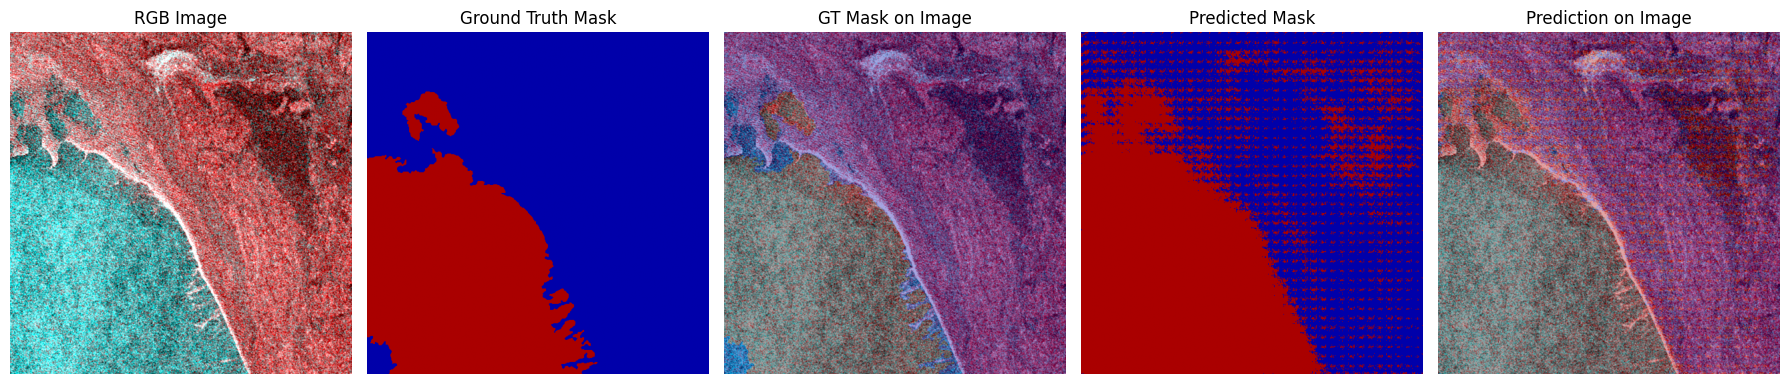

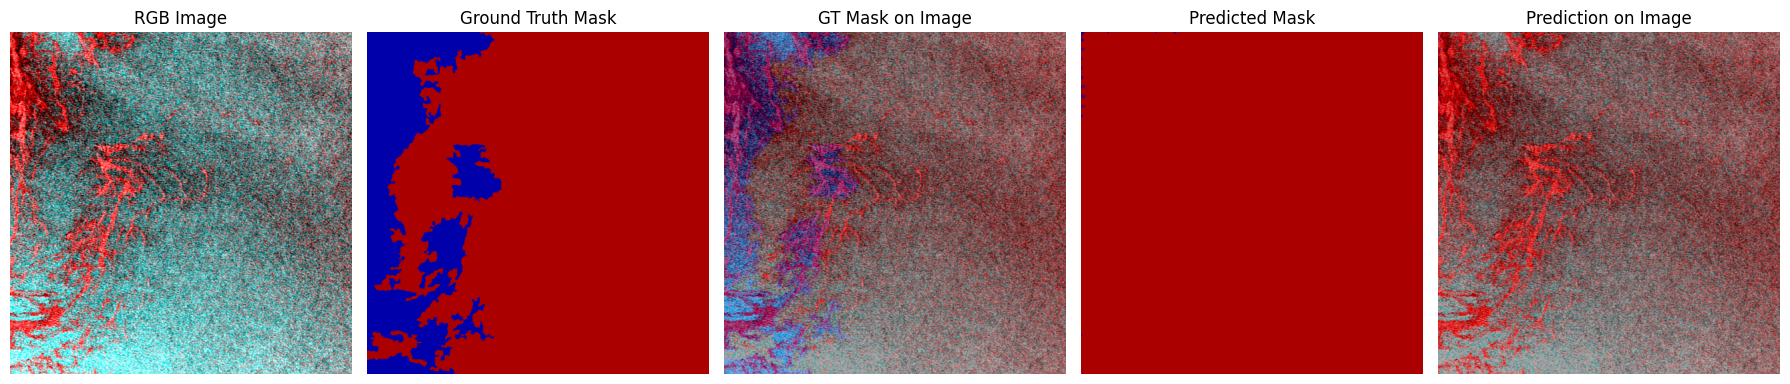

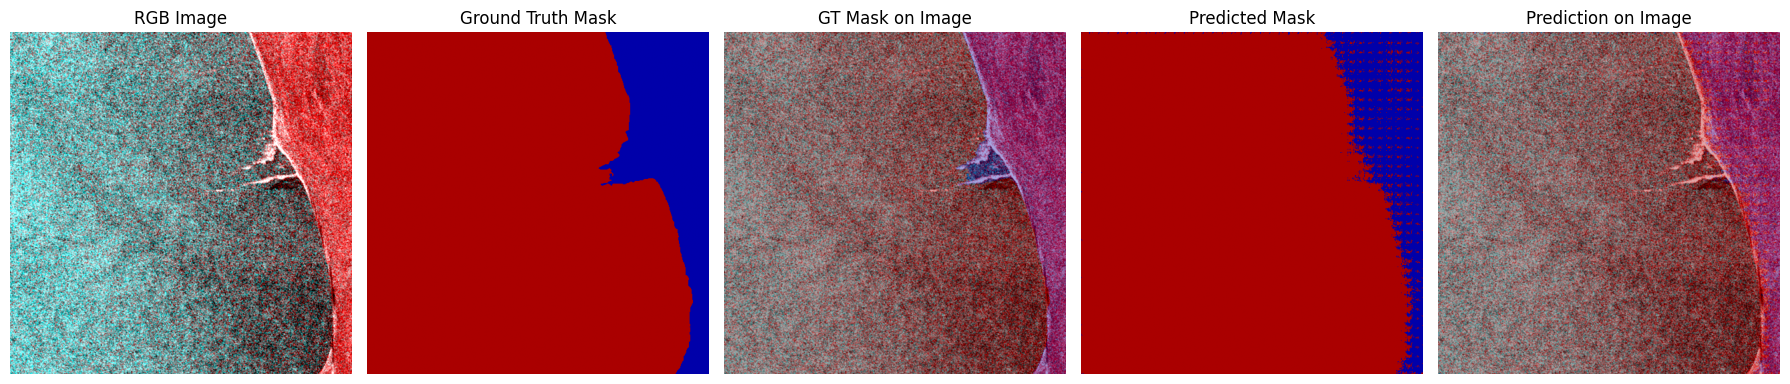

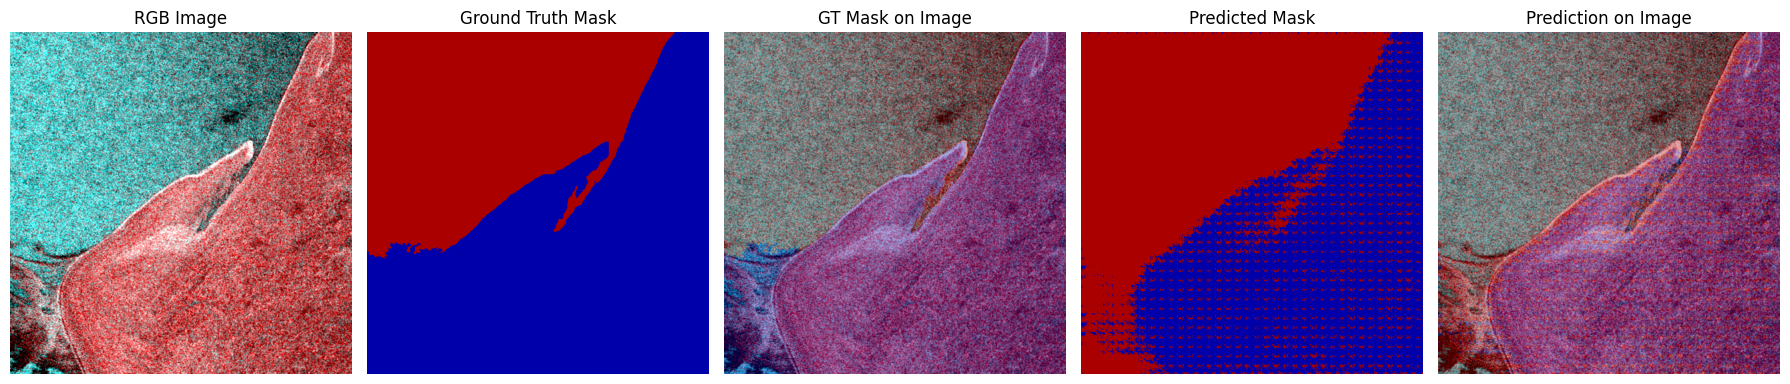

In [12]:
CLASS_COLORS = {
    0: "#0000AA",  
    1: "#AA0000",  
}

cmap = mcolors.ListedColormap([CLASS_COLORS[0], CLASS_COLORS[1]])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

def robust_minmax(x, p_low=2, p_high=98):
    lo = np.percentile(x, p_low)
    hi = np.percentile(x, p_high)
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    x = np.clip(x, lo, hi)
    return ((x - lo) / (hi - lo)).astype(np.float32)

def make_s1_rgb(sample_chw, s1_means, s1_stds):
    hh = sample_chw[0] * s1_stds[0] + s1_means[0]
    hv = sample_chw[1] * s1_stds[1] + s1_means[1]

    r = robust_minmax(hh)
    g = robust_minmax(hv)
    b = robust_minmax(hv)

    return np.stack([r, g, b], axis=-1)

def overlay_mask_on_rgb(rgb, mask, alpha=0.35):
    color_mask = cmap(norm(mask))[..., :3]
    return (1 - alpha) * rgb + alpha * color_mask

def get_logits(output):
    if hasattr(output, "output"):
        return output.output
    return output

datamodule.setup("test")
test_loader = datamodule.test_dataloader()

device = "cuda" if torch.cuda.is_available() else "cpu"
task.to(device)
task.eval()

with torch.no_grad():
    batch_idx = 2
    for j, batch in enumerate(test_loader):
        if j == batch_idx:
            break


    images = batch["image"].to(device)
    outputs = task(images)
    logits = get_logits(outputs)
    preds = torch.argmax(logits, dim=1).cpu().numpy()

images_np = batch["image"].cpu().numpy()
masks_np = batch["mask"].cpu().numpy()

num_examples = min(6, len(preds))

for i in range(num_examples):
    img = images_np[i]
    gt = masks_np[i]
    pred = preds[i]

    rgb = make_s1_rgb(img, S1_MEANS, S1_STDS)
    gt_overlay = overlay_mask_on_rgb(rgb, gt)
    pred_overlay = overlay_mask_on_rgb(rgb, pred)

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    axes[0].imshow(rgb)
    axes[0].set_title("RGB Image")

    axes[1].imshow(gt, cmap=cmap, norm=norm)
    axes[1].set_title("Ground Truth Mask")

    axes[2].imshow(gt_overlay)
    axes[2].set_title("GT Mask on Image")

    axes[3].imshow(pred, cmap=cmap, norm=norm)
    axes[3].set_title("Predicted Mask")

    axes[4].imshow(pred_overlay)
    axes[4].set_title("Prediction on Image")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()